In [ ]:
!pip install librosa tensorflow scikit-learn matplotlib numpy tqdm -q
print("All libraries installed!")

All libraries installed!


In [ ]:
import gdown, zipfile, os

url = "https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip"
output = "ravdess.zip"

print("Downloading RAVDESS dataset... (this may take 2-3 minutes)")
# gdown.download(url, output, quiet=False, fuzzy=True)

# If gdown fails, use wget instead:
!wget -q "https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip" -O ravdess.zip

print("Extracting...")
with zipfile.ZipFile("ravdess.zip", "r") as z:
    z.extractall("ravdess")

print("Done! Files are in /ravdess/")

Extracting...
Done! Files are in /ravdess/


In [ ]:
import os

all_files = []
for root, dirs, files in os.walk("ravdess"):
    for f in files:
        if f.endswith(".wav"):
            all_files.append(os.path.join(root, f))

print(f"Total audio files found: {len(all_files)}")
print("\nExample filename:", all_files[0])
print("\nFilename breakdown (RAVDESS naming system):")
print("Format: 03-01-EMOTION-intensity-statement-repetition-actor.wav")

# Emotion codes in RAVDESS
emotion_map = {
    '01': 'neutral', '02': 'calm', '03': 'happy',
    '04': 'sad',     '05': 'angry', '06': 'fearful',
    '07': 'disgust', '08': 'surprised'
}
print("\nEmotion codes:", emotion_map)

Total audio files found: 1440

Example filename: ravdess/Actor_08/03-01-08-02-01-02-08.wav

Filename breakdown (RAVDESS naming system):
Format: 03-01-EMOTION-intensity-statement-repetition-actor.wav

Emotion codes: {'01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad', '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'}


Spectrogram shape: (128, 128)


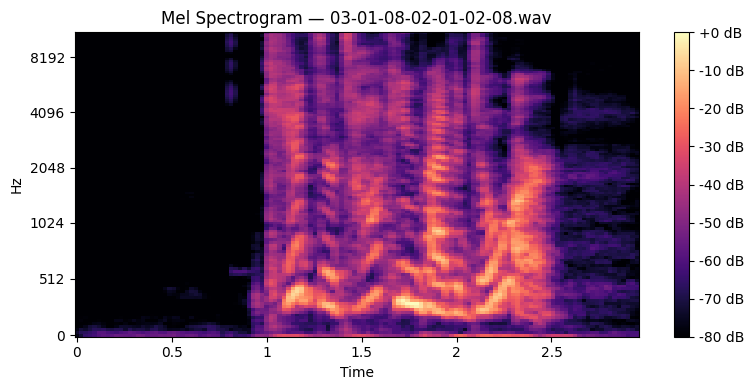

In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

def extract_melspectrogram(file_path, max_len=128):
    y, sr = librosa.load(file_path, sr=22050, duration=3.0)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Pad or trim to fixed width
    if mel_db.shape[1] < max_len:
        pad = max_len - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0,0),(0,pad)), mode='constant')
    else:
        mel_db = mel_db[:, :max_len]

    return mel_db

# Test it on one file
sample = all_files[0]
mel = extract_melspectrogram(sample)
print("Spectrogram shape:", mel.shape)  # Should be (128, 128)

plt.figure(figsize=(8, 4))
librosa.display.specshow(mel, sr=22050, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram — " + os.path.basename(sample))
plt.tight_layout()
plt.show()

In [ ]:
from tqdm import tqdm

emotion_map = {
    '01': 0, '02': 1, '03': 2, '04': 3,
    '05': 4, '06': 5, '07': 6, '08': 7
}
label_names = ['neutral','calm','happy','sad','angry','fearful','disgust','surprised']

X, y = [], []

print("Processing all audio files...")
for fp in tqdm(all_files):
    fname = os.path.basename(fp)
    parts = fname.replace(".wav","").split("-")
    if len(parts) < 7:
        continue
    emotion_code = parts[2]
    if emotion_code not in emotion_map:
        continue
    mel = extract_melspectrogram(fp)
    X.append(mel)
    y.append(emotion_map[emotion_code])

X = np.array(X)[..., np.newaxis]  # Add channel dim for CNN: (N, 128, 128, 1)
y = np.array(y)

print(f"\nDataset ready!")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Emotion distribution:")
for i, name in enumerate(label_names):
    count = np.sum(y == i)
    print(f"  {name}: {count} samples")

Processing all audio files...


100%|██████████| 1440/1440 [00:17<00:00, 80.19it/s]


Dataset ready!
X shape: (1440, 128, 128, 1)
y shape: (1440,)
Emotion distribution:
  neutral: 96 samples
  calm: 192 samples
  happy: 192 samples
  sad: 192 samples
  angry: 192 samples
  fearful: 192 samples
  disgust: 192 samples
  surprised: 192 samples


In [ ]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fix normalisation — this was the main issue
mean = X_train.mean()
std = X_train.std() + 1e-8
X_train = (X_train - mean) / std
X_test  = (X_test  - mean) / std

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Mean: {mean:.4f} | Std: {std:.4f}")  # std should be ~15-25

# Bigger, better CNN
model = models.Sequential([
    layers.Input(shape=(128, 128, 1)),

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    # Block 4
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(8, activation='softmax')
])

# Lower learning rate — this fixes the unstable val_loss you saw
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Train: 1152 samples | Test: 288 samples
Mean: -59.8178 | Std: 19.1635


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,108,072 (34.74 MB)

 Trainable params: 9,106,088 (34.74 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    # Stop if val_loss doesn't improve for 10 epochs
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),

    # Cut learning rate in half if stuck for 5 epochs
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),

    # Save the best version automatically
    ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

history = model.fit(
    X_train, y_train,
    epochs=100,          # more epochs — early stopping will kick in when ready
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

print(f"\nBest val accuracy: {max(history.history['val_accuracy'])*100:.1f}%")

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.1775 - loss: 2.7494
Epoch 1: val_accuracy improved from None to 0.10405, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
31/31 ━━━━━━━━━━━━━━━━━━━━ 37s 570ms/step - accuracy: 0.2441 - loss: 2.4298 - val_accuracy: 0.1040 - val_loss: 2.5076 - learning_rate: 3.0000e-04
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.3438 - loss: 1.9830
Epoch 2: val_accuracy did not improve from 0.10405
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.3483 - loss: 1.9052 - val_accuracy: 0.1040 - val_loss: 3.4006 - learning_rate: 3.0000e-04
Epoch 3/100
30/31 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.3967 - loss: 1.7247
Epoch 3: val_accuracy improved from 0.10405 to 0.14451, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.4045 - loss: 1.6654 - val_accuracy: 0.1445 - val_loss: 5.0227 - learning_rate: 3.0000e-04
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4711 - loss: 1.4685
Epoch 4: val_accuracy did not improve from 0.14451
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.4893 - loss: 1.4512 - val_accuracy: 0.1445 - val_loss: 6.7039 - learning_rate: 3.0000e-04
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4594 - loss: 1.4239
Epoch 5: val_accuracy did not improve from 0.14451
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.4811 - loss: 1.3789 - val_accuracy: 0.1445 - val_loss: 8.1155 - learning_rate: 3.0000e-04
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5749 - loss: 1.2349
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.

Epoch 6: val_accuracy did not improve from 0.14451
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 5


Epoch 9: finished saving model to best_model.h5
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.6302 - loss: 0.9924 - val_accuracy: 0.1792 - val_loss: 10.8394 - learning_rate: 1.5000e-04
Epoch 10/100
30/31 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6519 - loss: 0.9200
Epoch 10: val_accuracy did not improve from 0.17919
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.6445 - loss: 0.9444 - val_accuracy: 0.1618 - val_loss: 11.8478 - learning_rate: 1.5000e-04
Epoch 11/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6766 - loss: 0.8582
Epoch 11: ReduceLROnPlateau reducing learning rate to 7.500000356230885e-05.

Epoch 11: val_accuracy did not improve from 0.17919
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.6691 - loss: 0.8860 - val_accuracy: 0.1676 - val_loss: 12.8058 - learning_rate: 1.5000e-04
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 1.

Best val accuracy: 17.9%



Test accuracy: 13.2%


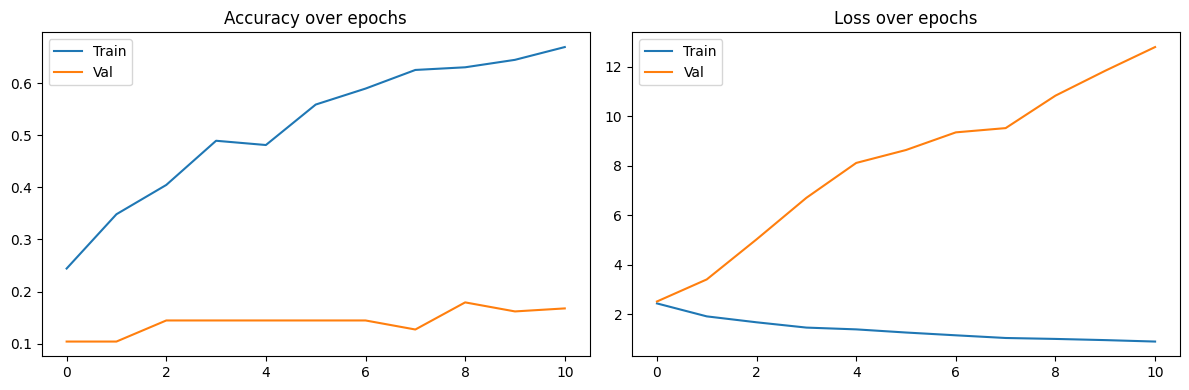

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


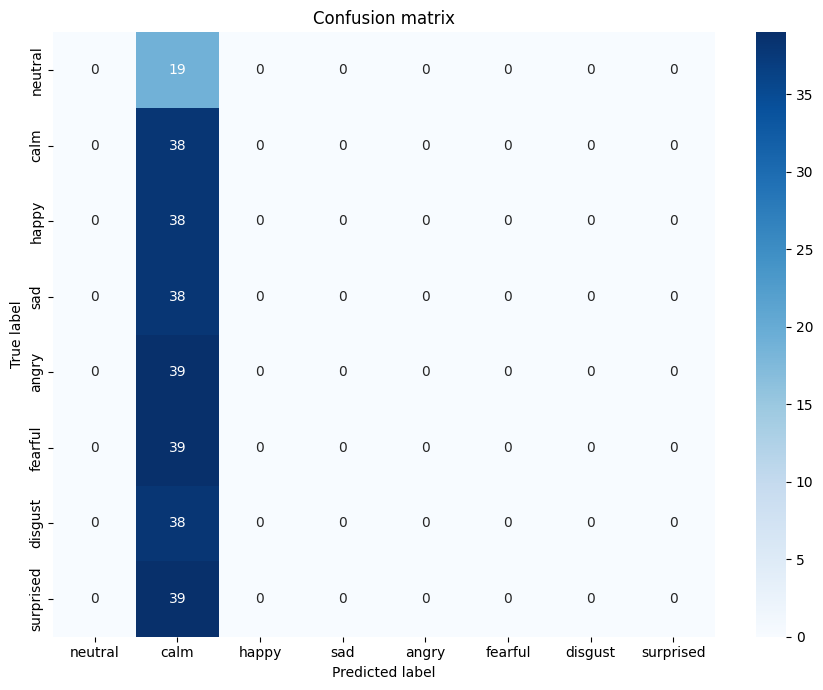


Detailed report:
              precision    recall  f1-score   support

     neutral       0.00      0.00      0.00        19
        calm       0.13      1.00      0.23        38
       happy       0.00      0.00      0.00        38
         sad       0.00      0.00      0.00        38
       angry       0.00      0.00      0.00        39
     fearful       0.00      0.00      0.00        39
     disgust       0.00      0.00      0.00        38
   surprised       0.00      0.00      0.00        39

    accuracy                           0.13       288
   macro avg       0.02      0.12      0.03       288
weighted avg       0.02      0.13      0.03       288



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Accuracy
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest accuracy: {test_acc*100:.1f}%")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy over epochs')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss over epochs')
axes[1].legend()
plt.tight_layout()
plt.show()

# Confusion matrix
y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_names, yticklabels=label_names, cmap='Blues')
plt.title('Confusion matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

print("\nDetailed report:")
print(classification_report(y_test, y_pred, target_names=label_names))

In [ ]:
model.save("emotion_model.h5")
print("Model saved as emotion_model.h5")

# To load it later:
# model = tf.keras.models.load_model("emotion_model.h5")

Model saved as emotion_model.h5


In [ ]:
# DIAGNOSTIC — paste this in a new cell and run it
import os

for f in all_files[:10]:
    fname = os.path.basename(f)
    parts = fname.replace(".wav", "").split("-")
    print(f"File: {fname}")
    print(f"  parts: {parts}")
    print(f"  emotion code picked (parts[2]): {parts[2]}")
    print()

File: 03-01-08-02-01-02-08.wav
  parts: ['03', '01', '08', '02', '01', '02', '08']
  emotion code picked (parts[2]): 08

File: 03-01-07-02-02-01-08.wav
  parts: ['03', '01', '07', '02', '02', '01', '08']
  emotion code picked (parts[2]): 07

File: 03-01-07-02-01-02-08.wav
  parts: ['03', '01', '07', '02', '01', '02', '08']
  emotion code picked (parts[2]): 07

File: 03-01-02-01-01-01-08.wav
  parts: ['03', '01', '02', '01', '01', '01', '08']
  emotion code picked (parts[2]): 02

File: 03-01-04-02-02-02-08.wav
  parts: ['03', '01', '04', '02', '02', '02', '08']
  emotion code picked (parts[2]): 04

File: 03-01-03-02-01-02-08.wav
  parts: ['03', '01', '03', '02', '01', '02', '08']
  emotion code picked (parts[2]): 03

File: 03-01-02-01-02-02-08.wav
  parts: ['03', '01', '02', '01', '02', '02', '08']
  emotion code picked (parts[2]): 02

File: 03-01-05-02-02-02-08.wav
  parts: ['03', '01', '05', '02', '02', '02', '08']
  emotion code picked (parts[2]): 05

File: 03-01-06-01-02-02-08.wav
 

In [ ]:
import librosa
import numpy as np
from google.colab import files

# --- upload any .wav file from your computer ---
print("Upload a .wav file:")
uploaded = files.upload()
audio_path = list(uploaded.keys())[0]

# --- convert to mel spectrogram (same way as training) ---
y, sr = librosa.load(audio_path, sr=22050, duration=3.0)
mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
mel_db = librosa.power_to_db(mel, ref=np.max)

# pad or trim to 128x128
if mel_db.shape[1] < 128:
    mel_db = np.pad(mel_db, ((0,0),(0, 128 - mel_db.shape[1])), mode='constant')
else:
    mel_db = mel_db[:, :128]

# normalise the same way as training
mel_db = (mel_db - X_train.mean()) / (X_train.std() + 1e-8)

# reshape for model input: (1, 128, 128, 1)
input_array = mel_db[np.newaxis, ..., np.newaxis]

# --- predict ---
label_names = ['neutral','calm','happy','sad','angry','fearful','disgust','surprised']
predictions = model.predict(input_array, verbose=0)[0]
top_emotion = label_names[np.argmax(predictions)]
confidence = predictions[np.argmax(predictions)]

# --- print results ---
print(f"\n--- Emotion Prediction ---")
print(f"Detected emotion : {top_emotion.upper()}")
print(f"Confidence       : {confidence*100:.1f}%")
print(f"\nAll scores:")
for name, score in sorted(zip(label_names, predictions), key=lambda x: -x[1]):
    bar = '█' * int(score * 30)
    print(f"  {name:<12} {score*100:5.1f}%  {bar}")

Upload a .wav file:


Saving WhatsApp Audio 2026-03-25 at 6.46.51 AM.wav to WhatsApp Audio 2026-03-25 at 6.46.51 AM.wav

--- Emotion Prediction ---
Detected emotion : DISGUST
Confidence       : 77.3%

All scores:
  disgust       77.3%  ███████████████████████
  happy         22.7%  ██████
  angry          0.0%  
  sad            0.0%  
  neutral        0.0%  
  fearful        0.0%  
  surprised      0.0%  
  calm           0.0%  


In [1]:
!git clone https://github.com/mariaroselind/Audio-to-Sign-Language-Video.git

Cloning into 'Audio-to-Sign-Language-Video'...


In [2]:
!ls

Audio-to-Sign-Language-Video  sample_data


In [3]:
%cd Audio-to-Sign-Language-Video

/content/Audio-to-Sign-Language-Video


In [4]:
!ls /content

Audio-to-Sign-Language-Video  sample_data


In [5]:
!ls -la

total 12
drwxr-xr-x 3 root root 4096 May 16 09:08 .
drwxr-xr-x 1 root root 4096 May 16 09:08 ..
drwxr-xr-x 7 root root 4096 May 16 09:08 .git


In [6]:
%cd /content

/content


In [7]:
!find /content -maxdepth 2

/content
/content/.config
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/configurations
/content/.config/.last_opt_in_prompt.yaml
/content/.config/active_config
/content/.config/gce
/content/.config/.last_survey_prompt.yaml
/content/.config/.last_update_check.json
/content/.config/default_configs.db
/content/.config/config_sentinel
/content/.config/logs
/content/Audio-to-Sign-Language-Video
/content/Audio-to-Sign-Language-Video/.git
/content/sample_data
/content/sample_data/anscombe.json
/content/sample_data/README.md
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_train_small.csv
